In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import math
sys.path.append('../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import Read_PDB
from scipy import integrate
#import h5py
#import plotly.express as px

In [2]:
import numpy as np

def generate_filled_sphere(radius, d):
    """
    Generate 3D coordinates filling a sphere of given radius with uniform spacing `d`.
    
    :param radius: Radius of the sphere
    :param d: Spacing between adjacent points
    :return: A NumPy array of shape (N, 3) containing 3D coordinates
    """
    points_list = []
    
    # Generate radial layers
    num_r = int(radius / d) + 1
    r_values = np.linspace(0, radius, num_r)

    for r in r_values:
        if r == 0:
            points_list.append([[0, 0, 0]])  # Center point
            continue
        
        # Compute number of points for angular distribution at this radius
        num_theta = max(1, int(2 * np.pi * r / d))  # Around the circle
        num_phi = max(1, int(np.pi * r / d))  # Along vertical
        
        theta_values = np.linspace(0, 2 * np.pi, num_theta, endpoint=False)  # Azimuthal angle
        phi_values = np.linspace(0, np.pi, num_phi)  # Polar angle
        
        # Create meshgrid
        Theta, Phi = np.meshgrid(theta_values, phi_values, indexing='ij')

        # Convert to Cartesian coordinates
        X = r * np.sin(Phi) * np.cos(Theta)
        Y = r * np.sin(Phi) * np.sin(Theta)
        Z = r * np.cos(Phi)

        # Store points
        points = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))
        points_list.append(points)

    # Combine all points into a single array
    all_points = np.vstack(points_list)
    
    return all_points

def create_sc_lattice(nx, ny, nz, d):
    """ Generate Simple Cubic (SC) lattice points """
    x = np.arange(0, nx) * d
    y = np.arange(0, ny) * d
    z = np.arange(0, nz) * d
    return np.array(np.meshgrid(x, y, z)).reshape(3, -1).T

def create_bcc_lattice(nx, ny, nz, d):
    """ Generate Body-Centered Cubic (BCC) lattice points """
    points = []
    for x in range(nx):
        for y in range(ny):
            for z in range(nz):
                points.append([x*d, y*d, z*d])
                points.append([x*d + d/2, y*d + d/2, z*d + d/2])
    return np.array(points)

def create_fcc_lattice(nx, ny, nz, d):
    """ Generate Face-Centered Cubic (FCC) lattice points """
    points = []
    for x in range(nx):
        for y in range(ny):
            for z in range(nz):
                points.append([x*d, y*d, z*d])
                points.append([x*d, y*d + d/2, z*d + d/2])
                points.append([x*d + d/2, y*d, z*d + d/2])
                points.append([x*d + d/2, y*d + d/2, z*d])
    return np.array(points)

def create_hcp_lattice(nx, ny, nz, d):
    points = []
    a = d
    c = np.sqrt(8/3) * a
    for x in range(nx):
        for y in range(ny):
            for z in range(nz):
                points.append([x*a, y*np.sqrt(3)*a, z*c])
                points.append([x*a + a/2, y*np.sqrt(3)*a + np.sqrt(3)*a/2, z*c])
                points.append([x*a + a/2, y*np.sqrt(3)*a + np.sqrt(3)*a/6, z*c + c/2])
                points.append([x*a, y*np.sqrt(3)*a + 2*np.sqrt(3)*a/3, z*c + c/2])
    return np.array(points)



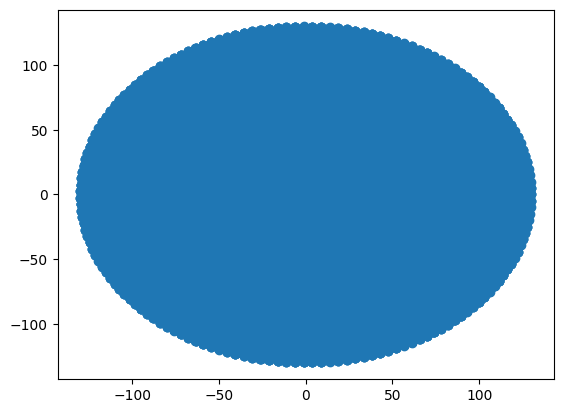

In [3]:
building_block = generate_filled_sphere(radius=130, d=5)
plt.scatter(building_block[:,0], building_block[:,1])

In [24]:
lattice_coordinates = create_fcc_lattice(10, 10, 10, 1200)
n_random = 0
random_displacement = (np.random.rand(lattice_coordinates.shape[0], 3) - 0.5)*n_random
lattice_coordinates = lattice_coordinates + random_displacement

(0.0, 1000.0)

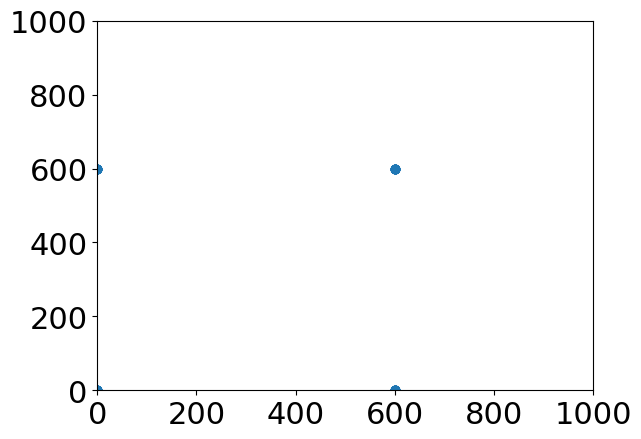

In [25]:
plt.scatter(lattice_coordinates[:,0], lattice_coordinates[:,1])
plt.xlim([0,1000])
plt.ylim([0,1000])

In [26]:
n_samples = 10000000
simulator = pairwise_method.scattering_simulator(n_samples)
simulator.sample_building_block(building_block)
simulator.sample_lattice_coordinates(lattice_coordinates)
simulator.calculate_structure_coordinates()
histogram_bins = 10000
q = np.geomspace(0.004, 3, 6000)
I_q = simulator.simulate_multiple_scattering_curves_lattice_coords(building_block, lattice_coordinates, histogram_bins, q, save=False).numpy()
#I_q = simulator.simulate_scattering_curve_fast_lattice(building_block, lattice_coordinates, histogram_bins, q, save=False).reshape(-1,1)

## Plot the Scattering Curve

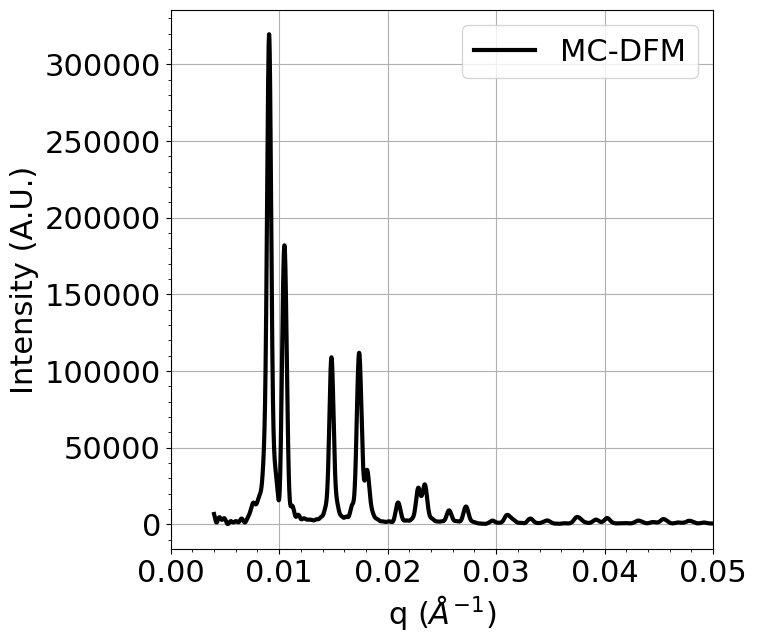

In [27]:
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7))
background = 0
plt.plot(q, np.mean(I_q, axis=1) + background, linewidth = 3, label = 'MC-DFM', color='k')
#plt.plot(q, np.mean(I_q_long, axis=1) + background, linewidth = 3, label = 'length = 480nm', color='red')
#data = pd.read_csv('../Data/scattering/zinc_oxide.csv').values
#plt.plot(q, I_q + background, linewidth = 3, label = 'MC-DFM', color='k')
#plt.scatter(data[:,0], data[:,1]*1e4)
#plt.yscale('log')
#plt.xscale('log')
plt.xlim([0, 0.05])
plt.ylabel('Intensity (A.U.)')
plt.xlabel('q ($\\AA^{-1}$)')
ax.minorticks_on()
plt.legend(loc=1)
plt.grid()
#plt.show()
#plt.savefig('../Images/Single_tube.png', dpi=600, bbox_inches="tight")
#data = np.hstack((q.reshape(-1,1), np.mean(I_q, axis=1).reshape(-1,1)))
#np.save('../Data/simulated_scattering/RhuA_3/RhuA_' + str(amp) + '_amp_' + str(start) + '_start_' + str(OD) + 'nm_OD.npy', data)

## Plot the Pairwise Distribution

Text(0.5, 0, 'Interatomic Distance ($\\AA$)')

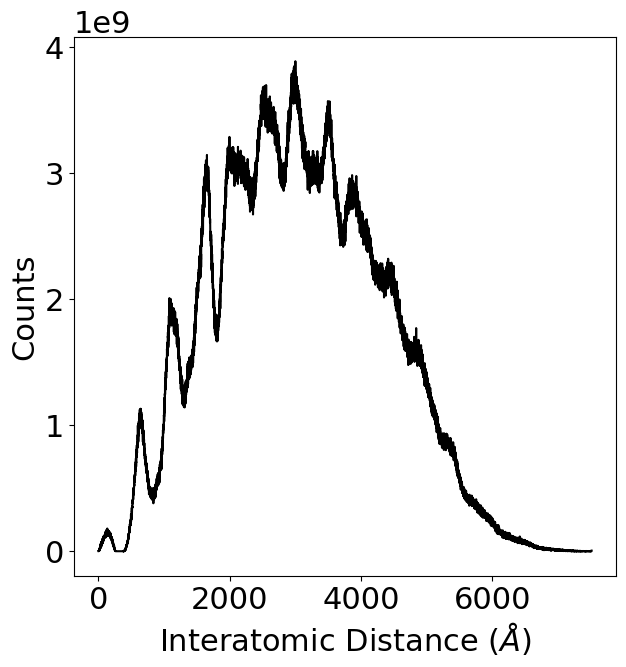

In [65]:
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(7,7))
plt.plot(simulator.r, simulator.p_r*1e6, color='k')
plt.ylabel('Counts')
plt.xlabel('Interatomic Distance ($\\AA$)')
#plt.savefig('../Images/RhuA/pairwise_dist_tubes.png', dpi=300, bbox_inches="tight")

To confirm which object the scattering curve belongs to, we can plot the randomly sampled coordiantes used to create the pairwise distribution. As expected, the object is the tube like structure made from assembling the RhuA protein. 

Text(0, 0.5, 'z axis [$\\AA$]')

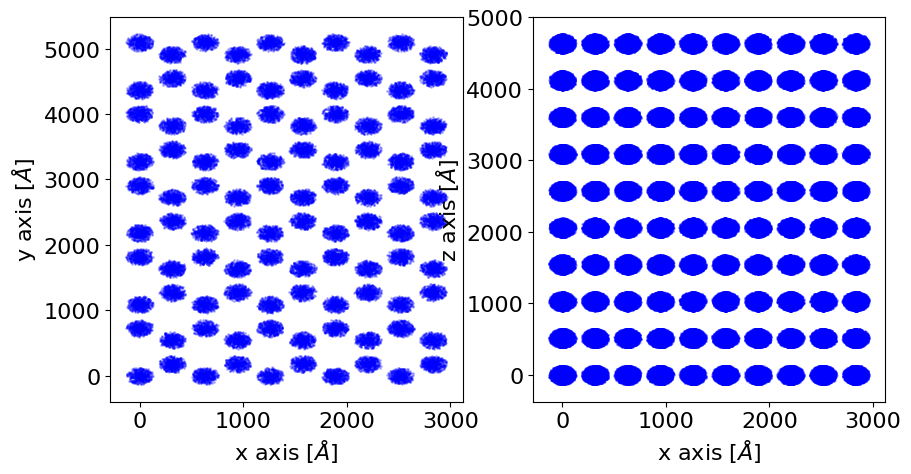

In [66]:
struc = simulator.structure_coordinates_1
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(10,5), ncols=2, nrows=1)
ax[0].scatter(struc[:,0][::50], struc[:,1][::50], alpha = 0.25, s=1, color = 'blue')
#ax[0].set_xlim([-100,100])
#ax[0].set_ylim([-100,100])
ax[0].set_xlabel('x axis [$\\AA$]')
ax[0].set_ylabel('y axis [$\\AA$]')
ax[1].scatter(struc[:,0][::10], struc[:,2][::10], alpha = 0.25, s=1, color = 'blue')
#ax[1].set_xlim([-1350,1350])
#ax[1].set_ylim([-100,2600])
ax[1].set_xlabel('x axis [$\\AA$]')
ax[1].set_ylabel('z axis [$\\AA$]')

#plt.savefig('../Images/Sampled_Electron_Density_Tube_assembly_2.png', dpi=300, bbox_inches="tight")